## Plotting derivative

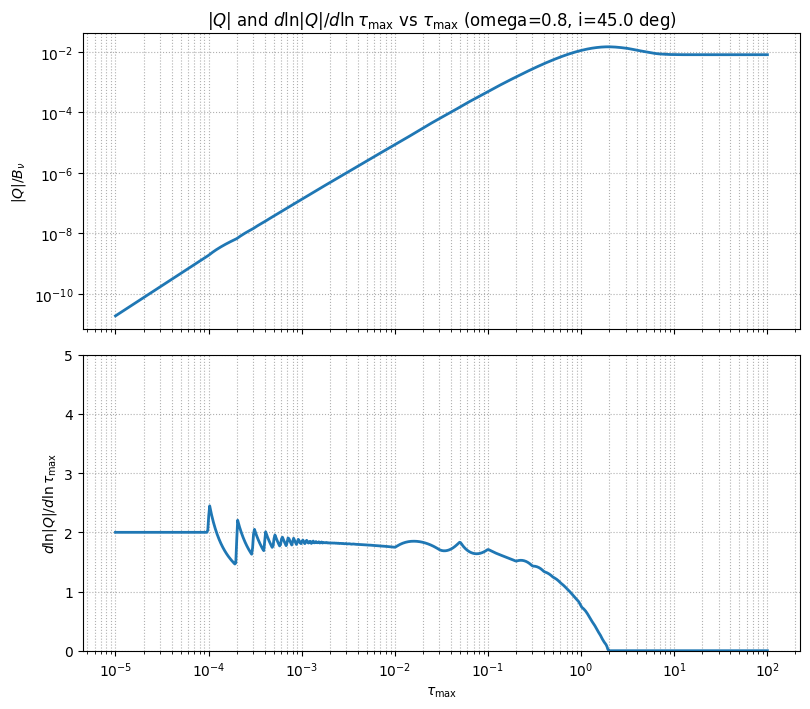

In [7]:
from emergentintensity import emergent_stokes, INTERP_TABLES, Q_THIN_TABLE

import numpy as np
import matplotlib.pyplot as plt

# =========================
# User parameters
# =========================
omega0 = 0.8
inc0   = 45.0
tau_vals = np.logspace(-5, 2, 700)  # 1e-5 ... 1e2

# =========================
# Ensure tables loaded
# =========================
# emergentintensity を import 済み（setup_tables, emergent_stokes, INTERP_TABLES, Q_THIN_TABLE が見える）前提
if INTERP_TABLES is None:
    setup_tables()

tau_grid = INTERP_TABLES["tau_grid"]
tau_min_table = float(tau_grid[0])
tau_1         = float(tau_grid[1])
tau_max_table = float(tau_grid[-1])

has_eq10 = (Q_THIN_TABLE is not None)
if has_eq10:
    tau_min_thin = float(Q_THIN_TABLE["tau_grid"][0])   # usually ~1e-4
    tau_max_thin = float(Q_THIN_TABLE["tau_grid"][-1])  # usually ~ tau_min_table
else:
    tau_min_thin = None
    tau_max_thin = None

# =========================
# Compute Q(tau) and dQ/dtau (patched)
# =========================
Q_arr = np.empty_like(tau_vals, dtype=float)
for i, t in enumerate(tau_vals):
    I, Q = emergent_stokes(float(t), float(omega0), float(inc0))
    Q_arr[i] = float(Q)

# Numerical derivative w.r.t. tau (not log-tau)
dQ_dtau = np.gradient(Q_arr, tau_vals)

# For log-log of Q, use absolute value (and clip zeros)
Qabs = np.abs(Q_arr)
Qabs = np.clip(Qabs, 1e-300, None)

# For linear plot of derivative: use absolute value, no clipping needed
dQabs = np.abs(dQ_dtau)

# =========================
# Helper: regime boundaries + annotations
# =========================
def _geom_mid(a, b):
    a = float(a); b = float(b)
    return 10.0 ** (0.5 * (np.log10(a) + np.log10(b)))

def _place_region_text(ax, x0, x1, text, yfrac=0.92, fontsize=9):
    xmid = _geom_mid(x0, x1)
    ax.text(
        xmid, yfrac, text,
        transform=ax.get_xaxis_transform(),  # x in data, y in axes fraction
        ha="center", va="top", fontsize=fontsize
    )

def _vline(ax, x, label=None, **kw):
    ax.axvline(x, **kw)
    if label is not None:
        ax.text(
            x, 0.02, label,
            transform=ax.get_xaxis_transform(),
            ha="center", va="bottom", fontsize=8, rotation=90
        )

# Q-based regime split boundaries (in increasing order)
bounds = [float(tau_vals.min())]

if has_eq10:
    if (tau_min_thin is not None) and (tau_vals.min() < tau_min_thin < tau_vals.max()):
        bounds.append(float(tau_min_thin))
    bounds.append(float(tau_min_table))
else:
    bounds.append(float(tau_min_table))

bounds.append(float(tau_1))
bounds.append(float(tau_max_table))
bounds.append(float(tau_vals.max()))

bounds = sorted(set([float(np.clip(b, tau_vals.min(), tau_vals.max())) for b in bounds]))
if bounds[0] != float(tau_vals.min()):
    bounds = [float(tau_vals.min())] + bounds
if bounds[-1] != float(tau_vals.max()):
    bounds = bounds + [float(tau_vals.max())]

region_labels = []
for j in range(len(bounds) - 1):
    a, b = bounds[j], bounds[j+1]
    tm = _geom_mid(a, b)

    if tm < tau_min_table:
        if has_eq10:
            if (tau_min_thin is not None) and (tm < tau_min_thin):
                region_labels.append("Q: Eq.(B.4) extension\n(matched to Eq.(10) at τ_min)")
            else:
                region_labels.append("Q: Eq.(10) table\n(trilinear interp)")
        else:
            region_labels.append("Q: thin approx ∝ τ²\n(matched to RT at τ_min)")
    elif tau_min_table <= tm <= tau_1:
        if has_eq10:
            region_labels.append("Q: Hermite bridge\n(Eq.(10) → RT)")
        else:
            region_labels.append("Q: Hermite bridge\n(thin → RT)")
    elif tau_1 < tm <= tau_max_table:
        region_labels.append("Q: RT interpolation\n(Hermite in τ)")
    else:
        region_labels.append("Q: saturation\n(clamp to τ_max_table)")

# --- Numerical derivative (slope in log-log) ---
# Q can be negative, so use |Q| and clip to avoid log(0)
Qabs = np.abs(Q_arr)
Qabs = np.clip(Qabs, 1e-300, None)

# log-log slope: d ln|Q| / d ln tau
dlogQ_dlogtau = np.gradient(np.log(Qabs), np.log(tau_vals))
dlogQ_dlogtau = np.clip(dlogQ_dlogtau, 0.0, 5.0)  # optional safety clip

# =========================
# Plot: |Q| (loglog) and slope (semilogx, linear y)
# =========================
fig, axes = plt.subplots(2, 1, figsize=(8.2, 7.2), sharex=True)
axQ, axS = axes

# |Q|
axQ.loglog(tau_vals, Qabs, lw=2)
axQ.set_ylabel(r"$|Q|/B_\nu$")
axQ.set_title(
    fr"$|Q|$ and $d\ln|Q|/d\ln\tau_{{\rm max}}$ vs $\tau_{{\rm max}}$ (omega={omega0}, i={inc0} deg)"
)
axQ.grid(True, which="both", ls=":")

# slope panel (linear y, x log)
axS.semilogx(tau_vals, dlogQ_dlogtau, lw=2)
axS.set_ylabel(r"$d\ln|Q|/d\ln\tau_{{\rm max}}$")
axS.set_xlabel(r"$\tau_{\rm max}$")
axS.grid(True, which="both", ls=":")
axS.set_ylim(0.0, 5.0)

plt.tight_layout()
plt.show()